# PhD Coding Challenge: Loan Approval Automation Exploration

## Setting up the directory, loading the required libraries, and importing the Loan dataset

In [1]:
# Loading the Directory where the Dataset is stored and this is also the folder where all the other, related notebooks will be stored.
%cd C:\Users\Jananisri\OneDrive\work_phd\phd\admission cycle papers\KU Leuven\coding-challenge-data-gov-fintech-main

C:\Users\Jananisri\OneDrive\work_phd\phd\admission cycle papers\KU Leuven\coding-challenge-data-gov-fintech-main


In [2]:
# Loading the necessary libraries needed for coding challenge

# For examining and to find out information about the features in the dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Libraries for data pre-processing and data exploration

import numpy_financial as nf # (install library if it's a new one - %pip install numpy-financial)
import seaborn as sns # for correlation heatmap
from sklearn.preprocessing import OneHotEncoder # data preprocessing for categorical features
from sklearn.preprocessing import RobustScaler # data preprocessing for continuous features

# Building the loan approval prediction model
from sklearn.model_selection import train_test_split # to split the data
from sklearn.linear_model import LogisticRegression # for logistic regression
from sklearn.svm import LinearSVC #for linear SVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix # for metrics on accuracy and precision of the models
from sklearn.feature_selection import SelectFromModel # for L1 penalty with logistic regression
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate # for tests on fairness and non-discrimination

C:\Users\Jananisri\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
df = pd.read_csv('loan_dataset.csv', parse_dates=['application_date'])
df.head()

,customer_id,age,income,loan_amount,loan_term_months,credit_score,employment_length_years,debt_to_income_ratio,savings_amount,previous_defaults,...,home_ownership,application_type,loan_purpose,has_cosigner,existing_customer,application_date,loan_to_income_ratio,monthly_payment,payment_to_income_ratio,loan_status
0,35467,63,48000.0,40600.0,48,850,4.5,0.167,11000.0,0,...,mortgage,in_person,business,0,1,2021-08-02,0.846,934.99,0.234,repaid
1,23067,38,31000.0,21600.0,48,707,4.1,0.116,16400.0,0,...,own,in_person,other,1,0,2023-02-05,0.697,497.43,0.193,repaid
2,8591,48,45000.0,26800.0,36,723,12.1,0.167,4700.0,0,...,mortgage,online,car,0,1,2023-10-17,0.596,803.22,0.214,repaid
3,9983,52,31000.0,22900.0,24,779,2.6,0.187,9000.0,0,...,rent,online,business,1,1,2022-06-06,0.739,1004.65,0.389,repaid
4,21525,55,22000.0,50300.0,12,675,4.7,0.111,21400.0,0,...,rent,online,car,1,0,2021-06-11,2.000,4306.06,0.500,default


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              50000 non-null  int64         
 1   age                      50000 non-null  int64         
 2   income                   50000 non-null  float64       
 3   loan_amount              50000 non-null  float64       
 4   loan_term_months         50000 non-null  int64         
 5   credit_score             50000 non-null  int64         
 6   employment_length_years  50000 non-null  float64       
 7   debt_to_income_ratio     50000 non-null  float64       
 8   savings_amount           50000 non-null  float64       
 9   previous_defaults        50000 non-null  int64         
 10  education_level          50000 non-null  object        
 11  zip_code_prefix          50000 non-null  int64         
 12  home_ownership           50000 n

### ABOUT THE COLUMNS: There are 21 features and 1 target column in this dataset.
Demographic features include age, education level, zip_code_prefix, and home_ownership.
Features regarding loan characteristics are loan_amount, loan_term_months, application_type, loan_purpose, has_cosigner, existing_customer, application_date, monthly_payment, and loan_status. 
Borrower features consist of (unique) customer_id, income, credit_score, employment_length_years, debt_to_income ratio, savings_amount, loan_to_income_ratio, payment_to_income_ratio.

### Sanity check regarding the features.
1. Are there any borrowers who are repeated in this dataset, i.e., non-unique observations of customer_id?
2. Is there any customer who has been working for more than the legal age requirement? (This would show if the dataset is not properly representative of the demographic features or customer's employment status).
3. If the loan is repaid ('loan_status' = "repaid"), then is the repayment amount > principal amount? At the calculated interest rate, is the total repayment amount correct?


In [5]:
# 1. Are there any duplicate customer_ids?
dupes = df[df.duplicated(subset=['customer_id'], keep=False)]
print("Number of non-unique rows:", dupes.shape[0])
print("Affected customer_ids:", dupes['customer_id'].unique())

# 2. Any customers whose reported employment_length_years is impossible?
# Here we flag anyone who claims to have worked more years than their age minus legal_working_age.
# Since, in Belgium, the lowest legal age to work under "restricted to light work", I chose 15 as the legal age.
legal_working_age = 15
mask_impossible = df['employment_length_years'] > (df['age'] - legal_working_age)
impossible_work = df[mask_impossible]
print("\nRows with impossible employment length (n={}):".format(impossible_work.shape[0]))
display(impossible_work[['customer_id','age','employment_length_years']])

Number of non-unique rows: 0
Affected customer_ids: []

Rows with impossible employment length (n=5694):


,customer_id,age,employment_length_years
6,14795,21,19.6
12,42415,25,17.4
13,9817,19,25.5
28,36780,40,40.0
29,46639,19,5.9
...,...,...,...
49958,31836,50,40.0
49966,18140,32,32.5
49971,13537,22,15.1
49984,16376,29,25.3


In [6]:
#3. Is the loan_status correctly mapped? Here, I use numpy_financial library to calculate the monthly and annual interest rates for the loan.
# I use this formula - https://www.investopedia.com/terms/e/equated_monthly_installment.asp - to calculate the interest rates.

def get_monthly_rate(row):
    return nf.rate(
        nper = int(row['loan_term_months']),     # total payments
        pmt  = -row['monthly_payment'],          # outflow, so negative
        pv   =  row['loan_amount'],              # present value
        fv   = 0,                                # fully amortizing
        when = 'end'
    )
df['monthly_rate']    = df.apply(get_monthly_rate, axis=1)

repaid = df[df['loan_status'] == 'repaid'].copy()
repaid['total_repaid'] = repaid['monthly_payment'] * repaid['loan_term_months']
repaid['overpaid'] = repaid['total_repaid'] > repaid['loan_amount']
any_overpaid   = repaid['overpaid'].any()
overpaid_rate  = repaid['overpaid'].mean()
print(f"Any loans overpaid? {any_overpaid}")
print(f"Overpaid rate: {overpaid_rate:.2%} ({repaid['overpaid'].sum()} of {len(repaid)})")

Any loans overpaid? True
Overpaid rate: 100.00% (31216 of 31216)


In [7]:
df['monthly_rate'].describe()

count    5.000000e+04
mean     4.166674e-03
std      4.997032e-07
min      4.161755e-03
25%      4.166441e-03
50%      4.166673e-03
75%      4.166893e-03
max      4.174282e-03
Name: monthly_rate, dtype: float64

## Examining the dataset and screening for different patterns and relationships between the (raw) features

### Descriptive statistics on the whole dataset

In [8]:
df.describe()

,customer_id,age,income,loan_amount,loan_term_months,credit_score,employment_length_years,debt_to_income_ratio,savings_amount,previous_defaults,zip_code_prefix,has_cosigner,existing_customer,application_date,loan_to_income_ratio,monthly_payment,payment_to_income_ratio,monthly_rate
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000,50000.000000,50000.000000,50000.000000,5.000000e+04
mean,25000.500000,44.002820,60133.980000,21040.558000,36.000960,708.522780,8.439446,0.142956,15077.48200,0.207300,28.619200,0.150080,0.59962,2022-07-01 06:45:31.968000256,0.442796,752.350952,0.173547,4.166674e-03
min,1.000000,18.000000,20000.000000,1000.000000,12.000000,500.000000,0.500000,0.010000,0.00000,0.000000,10.000000,0.000000,0.00000,2021-01-01 00:00:00,0.007000,18.870000,0.003000,4.161755e-03
25%,12500.750000,31.000000,38000.000000,12100.000000,24.000000,656.000000,2.800000,0.080000,4400.00000,0.000000,20.000000,0.000000,0.00000,2021-09-29 00:00:00,0.198000,361.560000,0.072000,4.166441e-03
50%,25000.500000,44.000000,55000.000000,18700.000000,36.000000,709.000000,6.100000,0.132000,10400.00000,0.000000,30.000000,0.000000,1.00000,2022-06-30 00:00:00,0.338000,583.490000,0.130000,4.166673e-03
75%,37500.250000,57.000000,76000.000000,27400.000000,48.000000,763.000000,11.600000,0.194000,21000.00000,0.000000,40.000000,0.000000,1.00000,2023-04-02 00:00:00,0.571000,934.990000,0.236000,4.166893e-03
max,50000.000000,70.000000,300000.000000,121700.000000,60.000000,850.000000,40.000000,0.453000,182900.00000,3.000000,50.000000,1.000000,1.00000,2023-12-31 00:00:00,2.000000,7644.750000,0.500000,4.174282e-03
std,14433.901067,15.269871,29597.663249,12160.538838,13.136706,76.931381,7.703984,0.080042,14954.04011,0.549156,11.978492,0.357153,0.48998,NaN,0.355419,619.605202,0.135225,4.997032e-07


In [9]:
df.groupby('loan_status')[['income', 'loan_amount', 'monthly_rate', 'savings_amount', 'debt_to_income_ratio', 'credit_score']].mean()

,income,loan_amount,monthly_rate,savings_amount,debt_to_income_ratio,credit_score
loan_status,,,,,,
default,58884.263203,22116.199957,0.004167,14171.135009,0.154252,657.075596
repaid,60885.987955,20393.298309,0.004167,15622.869682,0.136158,739.480747


### Loan features

In [10]:
df['loan_status'].value_counts()

loan_status
repaid     31216
default    18784
Name: count, dtype: int64

### From the above below, we see that the repayment rate is 62.4%.

In [11]:
df['loan_status'].value_counts(normalize=True)

loan_status
repaid     0.62432
default    0.37568
Name: proportion, dtype: float64

### How correlated are the features?

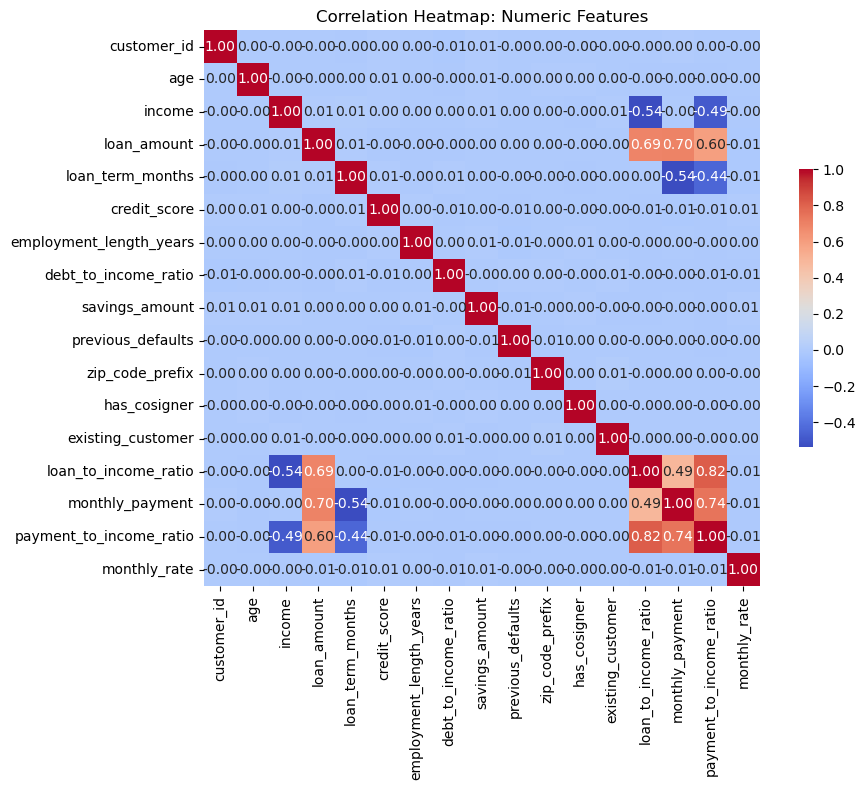

In [12]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={'shrink': .5})
plt.title("Correlation Heatmap: Numeric Features")
plt.tight_layout()
plt.show()

#### Key correlations
1. Income and Loan_to_Income ratio = -0.54
2. Loan Amount and Loan_to_Income ratio = 0.69
3. Loan Amount and Monthly Payment towards the loan = 0.7
4. Loan Amount and Payment_to_Income ratio = 0.6
5. Income and Payment_to_Income ratio = -0.49
6. Loan Term Months and Payment to Income ratio = -0.44
7. Monthly Payment and Loan to Income ratio = 0.49
8. Payment to Income ratio and Loan to Income ratio = 0.82
9. Monthly payment and Payment to Income ratio = 0.74

### Questions that I explore in this section (are there any other patterns that give away the protected attributes or more insight into what could be driving loan repayments and defaults)?

Note: I ask these questions while keeping in mind that the dataset consists only of "approved" loans. We need counterfactuals (dataset which consists of all "applied" loans to clearly answer the questions on what are the factors that drive approvals and rejections of loan applications).

1. What is the population of loans given to each zip_code_prefix, is there any partiality towards certain areas? What are the demographies of the customers in each Zip code? Do certain people not pay, are they young, what is the education, income-level in each area, and so on? Are the repayments(defaults) higher(lower) in certain areas?
2. If customers default on their payments by what amount do they default? Is it egregiously large or is the payment negligible? Is this driven by some demographical feature?
3. For the customers who default, how leverage are they compared to the ones who have repaid? (metrics: savings, debt to income, has_cosigner)

#### Q1. Zip-code populations, demography and local default rate

In [13]:
# Default rate by zip
by_zip = (
    df
    .groupby('zip_code_prefix')
    .agg(
        total_loans   = ('customer_id','count'),
        defaults      = ('loan_status', lambda s: (s=='default').sum()),
        default_rate  = ('loan_status', lambda s: np.mean(s=='default'))
    )
    .reset_index()
)

# Demographics by zip
demo_by_zip = (
    df
    .groupby('zip_code_prefix')
    .agg(
        avg_age       = ('age','mean'),
        median_income = ('income','median'),
        avg_cs        = ('credit_score','mean'),
        pct_high_edu  = ('education_level', lambda s:np.mean(s=='masters') + np.mean(s=='phd')),
        pct_high_school_only = ('education_level', lambda s:np.mean(s=='high_school'))
                         
    )
    .reset_index()
)

zip_summary = by_zip.merge(demo_by_zip, on='zip_code_prefix')
zip_summary.sort_values('total_loans', ascending=False).head(10)

,zip_code_prefix,total_loans,defaults,default_rate,avg_age,median_income,avg_cs,pct_high_edu,pct_high_school_only
2,30,15034,5643,0.375349,44.079287,55000.0,707.998936,0.304377,0.300120
1,20,12323,4489,0.364278,43.629068,54000.0,708.120019,0.294977,0.301793
3,40,10067,3891,0.386510,44.133406,56000.0,709.083938,0.303566,0.298897
0,10,7450,2664,0.357584,44.220671,55000.0,709.129933,0.296644,0.302282
4,50,5126,2097,0.409091,44.103980,54000.0,709.042918,0.314085,0.301210


#### Q2. How much amount do defaulters leave unpaid?

In [15]:
defaulted = df[df['loan_status']=='default'].copy()
defaulted['amount_repaid']= defaulted['monthly_payment'] * defaulted['loan_term_months']
defaulted['amount_defaulted'] = defaulted['loan_amount'] - defaulted['amount_repaid']
defaulted['amount_defaulted'].describe()

count    18784.000000
mean     -1748.491054
std       1232.029184
min     -12658.800000
25%      -2308.320000
50%      -1449.920000
75%       -857.280000
max        -38.200000
Name: amount_defaulted, dtype: float64

In [17]:
# Do demographical features drive this?
# Education level
defaulted.groupby('education_level')['amount_defaulted'] \
          .agg(['count','mean','median','quantile']) \
          .reset_index()

,education_level,count,mean,median,quantile
0,bachelors,7463,-1748.162465,-1444.00,-1444.00
1,high_school,5974,-1749.794998,-1468.56,-1468.56
2,masters,3574,-1747.651975,-1444.00,-1444.00
3,phd,1773,-1747.172025,-1444.00,-1444.00


In [18]:
#Zip area
defaulted.groupby('zip_code_prefix')['amount_defaulted'] \
          .agg(['count','mean','median','quantile']) \
          .reset_index()

,zip_code_prefix,count,mean,median,quantile
0,10,2664,-1823.704970,-1528.64,-1528.64
1,20,4489,-1731.842869,-1436.92,-1436.92
2,30,5643,-1732.360312,-1433.84,-1433.84
3,40,3891,-1752.729684,-1468.20,-1468.20
4,50,2097,-1724.121526,-1428.60,-1428.60


In [19]:
#Home ownership
defaulted.groupby('home_ownership')['amount_defaulted'] \
          .agg(['count','mean','median','quantile']) \
          .reset_index()

,home_ownership,count,mean,median,quantile
0,mortgage,7706,-1746.036704,-1445.66,-1445.66
1,own,4612,-1758.902454,-1455.04,-1455.04
2,rent,6466,-1743.989947,-1444.56,-1444.56


In [20]:
# Does age drive the magnitude of defaults?
age_bins   = [0, 25, 35, 45, 55, 65, np.inf]
age_labels = ['<=25', '26-35', '36-45', '46-55', '56-65', '66+']

defaulted['age_bin'] = pd.cut(
    defaulted['age'],
    bins=age_bins,
    labels=age_labels,
    right=True    # intervals are right-closed, e.g. (25,35]
)

defaulted.groupby('age_bin')['amount_defaulted'] \
          .agg(['count','mean','median','quantile']) \
          .reset_index()

C:\Users\Jananisri\AppData\Local\Temp\ipykernel_3064\4250334560.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  defaulted.groupby('age_bin')['amount_defaulted'] \


,age_bin,count,mean,median,quantile
0,<=25,2903,-1752.130637,-1452.56,-1452.56
1,26-35,3468,-1746.109227,-1444.92,-1444.92
2,36-45,3444,-1772.510337,-1481.60,-1481.60
3,46-55,3410,-1744.786991,-1468.38,-1468.38
4,56-65,3614,-1737.562269,-1428.82,-1428.82
5,66+,1945,-1731.575650,-1405.28,-1405.28


#### Q3. How leveraged are the borrowers?

In [21]:
lever_stats = (
    df
    .groupby('loan_status')
    .agg(
        avg_savings      = ('savings_amount','mean'),
        median_savings   = ('savings_amount','median'),
        avg_dti          = ('debt_to_income_ratio','mean'),
        pct_cosigner     = ('has_cosigner', lambda s: np.mean(s)),
        pct_existing     = ('existing_customer', lambda s: np.mean(s))
    )
    .reset_index()
)

lever_stats

,loan_status,avg_savings,median_savings,avg_dti,pct_cosigner,pct_existing
0,default,14171.135009,9700.0,0.154252,0.152310,0.581772
1,repaid,15622.869682,10900.0,0.136158,0.148738,0.610360


#### Binning the credit scores to see the default rates across different bins

In [22]:
credit_bins  = [0, 580, 670, 740, 800, np.inf]
credit_labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']

df['credit_score_bin'] = pd.cut(
    df['credit_score'],
    bins=credit_bins,
    labels=credit_labels,
    right=False    # intervals are left-closed, e.g. [580,670)
)

print(df['credit_score_bin'].value_counts())

credit_score_bin
Good         16762
Fair         12985
Very Good    11151
Excellent     6599
Poor          2503
Name: count, dtype: int64


C:\Users\Jananisri\AppData\Local\Temp\ipykernel_3064\196680286.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_cs = df.groupby(['credit_score_bin', 'loan_status']).size().unstack(fill_value=0)


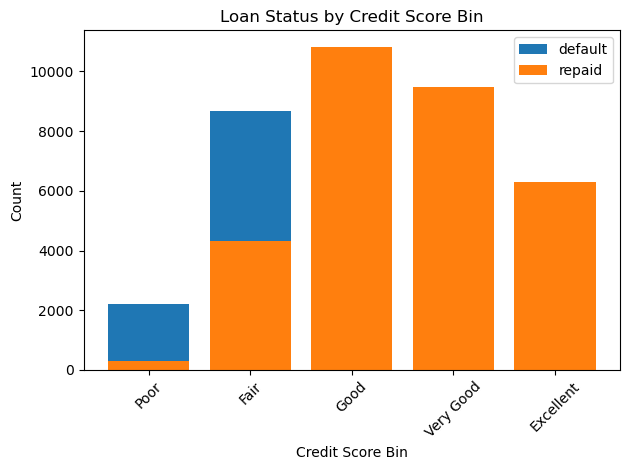

In [23]:
counts_cs = df.groupby(['credit_score_bin', 'loan_status']).size().unstack(fill_value=0)
fig, ax = plt.subplots()
for status in counts_cs.columns:
    ax.bar(counts_cs.index, counts_cs[status], label=status)
ax.set_title('Loan Status by Credit Score Bin')
ax.set_xlabel('Credit Score Bin')
ax.set_ylabel('Count')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Pre-processing the data

### One Hot Encoding
I use one-hot encoding to transform categorical features like educational level, area zip code, home ownership, application type, and purpose of applying for the loan. I also map the loan_status outcomes ('repaid' and 'default') to numeric labels of 1 and 0 respectively.

In [24]:
# Categorical features
low_card_cols = [
    'education_level',
    'zip_code_prefix',
    'home_ownership',
    'application_type',
    'loan_purpose',
] #low_card -> low cardinality
ohe = OneHotEncoder(
    sparse=False,
    handle_unknown='ignore',
)
encoded_arr = ohe.fit_transform(df[low_card_cols])
encoded_cols = ohe.get_feature_names_out(low_card_cols)
df_ohe = pd.DataFrame(encoded_arr, columns=encoded_cols, index=df.index)
df = pd.concat([
    df.drop(columns=low_card_cols),
    df_ohe
], axis=1)

# Loan Status
df['loan_status_binary'] = df['loan_status'].map({'repaid': 1, 'default': 0})
df = df.drop(columns=['loan_status'])

C:\Users\Jananisri\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


### Scaling the continuous variable

The univariate distribution plots show that the continous variables are skewed. To circumvent this, I can either use log-transformation or standardize the features. Towards that end, I use Robust Scaler option to scale the continous features.

Before scaling, I also save the dataset transformed till this point, as 'df_unscaled.csv'. I do that to show how scaling transformation improves accuracy of the loan approval model later.

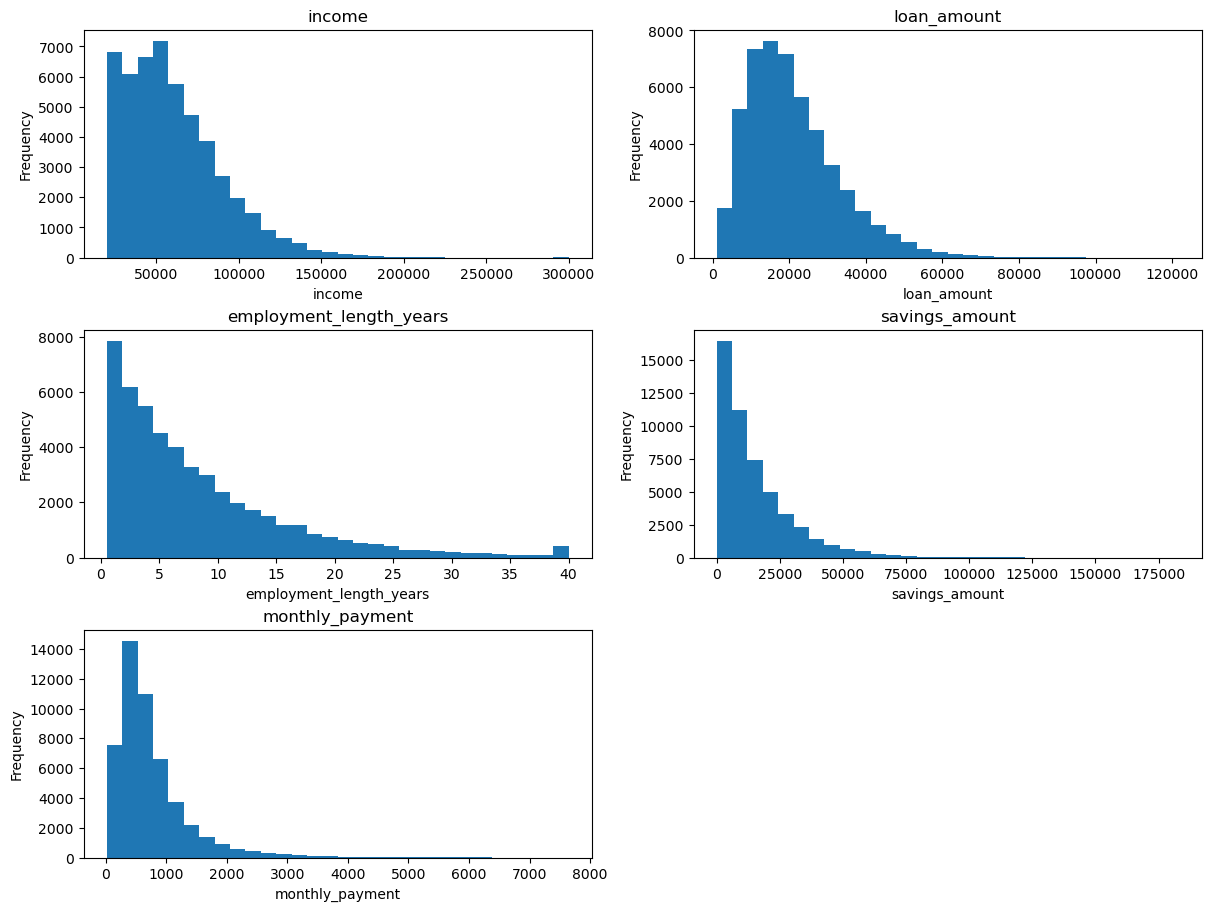

In [25]:
# continuous features
cont_vars = ['income', 'loan_amount','employment_length_years','savings_amount', 'monthly_payment']
n_vars = len(cont_vars)
n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols))

# plotting the univariate distributions / histograms
fig, axes = plt.subplots(n_rows, n_cols,figsize=(12, n_rows * 3),constrained_layout=True)
axes = axes.flatten()

# plot each histogram
for i, var in enumerate(cont_vars):
    ax = axes[i]
    data = df[var].dropna()
    ax.hist(data, bins=30)
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel('Frequency')

for j in range(n_vars, len(axes)): fig.delaxes(axes[j])

plt.show()

In [26]:
df.to_csv('df_unscaled.csv', index=False)

In [27]:
df_unscaled = pd.read_csv('df_unscaled.csv', parse_dates=['application_date'])

In [28]:
# Scaling the continuous features
cont_vars = ['income', 'loan_amount','employment_length_years','savings_amount', 'monthly_payment', 'debt_to_income_ratio',
            'loan_to_income_ratio', 'payment_to_income_ratio']
scaler = RobustScaler()
df[cont_vars] = scaler.fit_transform(df[cont_vars])

## Building the loan approval automation model(s)

### In this section, I will finally build the loan approval models. Since the target variable here is Loan Status, which is a binary variable I'll be focusing on two classfication algorithms namely, logistic regression algorithm and linear support vector classification algorithm. 

### Creating the test and train sample with the unscaled dataset (df_unscaled.csv)

In [31]:
# Creating train and test sample with the unscaled dataset
from sklearn.model_selection import train_test_split

# Defining X and y
X = df_unscaled.drop(columns=['loan_status_binary', 'customer_id', 'application_date', 'credit_score_bin'])
y = df_unscaled['loan_status_binary']

# 75/25 data split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=42,stratify=y)

print("Train size:", X_train.shape[0])
print("Test size: ", X_test.shape[0])

Train size: 37500
Test size:  12500


In [32]:
# Baseline models with unscaled data

# Logistic Regression
log_clf = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)
log_clf.fit(X_train, y_train)

# Predictions & probabilities
y_pred_log  = log_clf.predict(X_test)
y_proba_log = log_clf.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_proba_log))
print()

######################################

# Linear SVC

svm_clf = LinearSVC(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)
svm_clf.fit(X_train, y_train)

# SVM doesn’t have predict_proba; use decision_function for AUC
y_pred_svm    = svm_clf.predict(X_test)
y_decision_svm = svm_clf.decision_function(X_test)

print("=== Linear SVM ===")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("ROC AUC:", roc_auc_score(y_test, y_decision_svm))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.52      0.57      0.54      4696
           1       0.72      0.69      0.70      7804

    accuracy                           0.64     12500
   macro avg       0.62      0.63      0.62     12500
weighted avg       0.65      0.64      0.64     12500

Confusion Matrix:
 [[2666 2030]
 [2454 5350]]
ROC AUC: 0.682456147723135



C:\Users\Jananisri\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


=== Linear SVM ===
              precision    recall  f1-score   support

           0       0.40      0.94      0.56      4696
           1       0.81      0.14      0.24      7804

    accuracy                           0.44     12500
   macro avg       0.60      0.54      0.40     12500
weighted avg       0.65      0.44      0.36     12500

Confusion Matrix:
 [[4427  269]
 [6688 1116]]
ROC AUC: 0.6185086034593713


C:\Users\Jananisri\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


#### The overall prediction metric for the logistic regression model is 0.682 and for the linear SVC model, it's 0.618. As we saw earlier the continuous variables are skewed, so I run the same model with the scaled data.

### Creating test and train sample with the scaled data (df.csv)

In [35]:
# Creating train and test sample with the unscaled dataset
from sklearn.model_selection import train_test_split

# Defining X and y
X = df.drop(columns=['loan_status_binary', 'customer_id', 'application_date', 'credit_score_bin'])
y = df['loan_status_binary']

# 75/25 data split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=42,stratify=y)

print("Train size:", X_train.shape[0])
print("Test size: ", X_test.shape[0])

Train size: 37500
Test size:  12500


In [36]:
# Baseline models with unscaled data

# Logistic Regression
log_clf = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)
log_clf.fit(X_train, y_train)

# Predictions & probabilities
y_pred_log  = log_clf.predict(X_test)
y_proba_log = log_clf.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_proba_log))
print()

######################################

# Linear SVM

svm_clf = LinearSVC(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)
svm_clf.fit(X_train, y_train)

# SVM doesn’t have predict_proba; use decision_function for AUC
y_pred_svm    = svm_clf.predict(X_test)
y_decision_svm = svm_clf.decision_function(X_test)

print("=== Linear SVM ===")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("ROC AUC:", roc_auc_score(y_test, y_decision_svm))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.65      0.76      0.70      4696
           1       0.84      0.75      0.79      7804

    accuracy                           0.76     12500
   macro avg       0.75      0.76      0.75     12500
weighted avg       0.77      0.76      0.76     12500

Confusion Matrix:
 [[3590 1106]
 [1931 5873]]
ROC AUC: 0.8351514249888888



C:\Users\Jananisri\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


=== Linear SVM ===
              precision    recall  f1-score   support

           0       0.45      0.97      0.62      4696
           1       0.95      0.30      0.45      7804

    accuracy                           0.55     12500
   macro avg       0.70      0.64      0.54     12500
weighted avg       0.76      0.55      0.52     12500

Confusion Matrix:
 [[4575  121]
 [5486 2318]]
ROC AUC: 0.8345799548477738


C:\Users\Jananisri\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


#### After rescaling, both algorithms - logistic regression has an ROC AUC score of 0.835 and linear SVC has performed (almost) equally with an ROC AUC score of 0.834.

### Now, I aim to build a parsimonious or a sparse model because in the previous models, I have used almost all independent features which seems unncessary. To produce to the parsimonious model, I use an L1 penalty in the logistic regression estimation that shrinks the coefficients of unncessary features to zero.

In [37]:
X = df.drop(columns=['customer_id','application_date','loan_status_binary', 'credit_score_bin'])
y = df['loan_status_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42,stratify=y)

# L1 penalizer
l1_selector = SelectFromModel(LogisticRegression(penalty='l1',solver='liblinear',class_weight='balanced',random_state=42),prefit=False)
l1_selector.fit(X_train, y_train)
mask = l1_selector.get_support()
selected_features = X_train.columns[mask]
print("Selected features:", selected_features.tolist())
X_train_sel = l1_selector.transform(X_train)
X_test_sel  = l1_selector.transform(X_test)


# 4A. Fit & evaluate Logistic Regression on selected features
log_clf = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)
log_clf.fit(X_train_sel, y_train)

y_pred_log  = log_clf.predict(X_test_sel)
y_proba_log = log_clf.predict_proba(X_test_sel)[:, 1]

print("\n=== Logistic Regression (L1-selected features) ===")
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_proba_log))


# 4B. Fit & evaluate Linear SVM on the same selected features
svm_clf = LinearSVC(max_iter=5000,class_weight='balanced',random_state=42)
svm_clf.fit(X_train_sel, y_train)

y_pred_svm    = svm_clf.predict(X_test_sel)
y_decision_svm = svm_clf.decision_function(X_test_sel)

print("\n=== Linear SVM (L1-selected features) ===")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("ROC AUC:", roc_auc_score(y_test, y_decision_svm))

Selected features: ['age', 'income', 'loan_amount', 'loan_term_months', 'credit_score', 'employment_length_years', 'debt_to_income_ratio', 'savings_amount', 'previous_defaults', 'has_cosigner', 'existing_customer', 'loan_to_income_ratio', 'monthly_payment', 'payment_to_income_ratio', 'education_level_bachelors', 'education_level_high_school', 'education_level_masters', 'education_level_phd', 'zip_code_prefix_10', 'zip_code_prefix_20', 'zip_code_prefix_30', 'zip_code_prefix_40', 'zip_code_prefix_50', 'home_ownership_mortgage', 'home_ownership_own', 'home_ownership_rent', 'application_type_in_person', 'application_type_online', 'application_type_phone', 'loan_purpose_business', 'loan_purpose_car', 'loan_purpose_debt_consolidation', 'loan_purpose_home_improvement', 'loan_purpose_other']

=== Logistic Regression (L1-selected features) ===
              precision    recall  f1-score   support

           0       0.65      0.77      0.70      3757
           1       0.84      0.75      0.79 

C:\Users\Jananisri\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(



=== Linear SVM (L1-selected features) ===
              precision    recall  f1-score   support

           0       0.88      0.06      0.11      3757
           1       0.64      1.00      0.78      6243

    accuracy                           0.64     10000
   macro avg       0.76      0.53      0.44     10000
weighted avg       0.73      0.64      0.53     10000

Confusion Matrix:
 [[ 222 3535]
 [  30 6213]]
ROC AUC: 0.8363364732674139


C:\Users\Jananisri\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


#### The penalization has not shaved some features off the model but it has slightly increased the acurracy to 0.836 for both models. So, with this information I use this as the final, hold-out model.

## Final Model

In [51]:
# Creating train and test sample with the unscaled dataset
from sklearn.model_selection import train_test_split

df = df.drop('credit_score_bin', axis=1)

# Defining X and y
X = df.drop(columns=['loan_status_binary', 'customer_id', 'application_date'])
y = df['loan_status_binary']

# 75/25 data split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=42,stratify=y)

print("Train size:", X_train.shape[0])
print("Test size: ", X_test.shape[0])

# Logistic Regression
log_clf = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)
log_clf.fit(X_train, y_train)

# Predictions & probabilities
y_pred_log  = log_clf.predict(X_test)
y_proba_log = log_clf.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_proba_log))
print()

Train size: 37500
Test size:  12500
=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.65      0.76      0.70      4696
           1       0.84      0.75      0.79      7804

    accuracy                           0.76     12500
   macro avg       0.75      0.76      0.75     12500
weighted avg       0.77      0.76      0.76     12500

Confusion Matrix:
 [[3590 1106]
 [1931 5873]]
ROC AUC: 0.8351514249888888



### Finally, the hold-out model is a ,logistic regression classification algorithm that has a predictive performance score of 0.835.

## Assessing the Hold-Out model - Human intervention and fairness checks

### Human Intervention

In [52]:
# test set
probs = log_clf.predict_proba(X_test)[:, 1] # test-set instance’s predicted probability of the “positive” outcome

# thresholds
T_low, T_high = 0.2, 0.8

# build review DataFrame
df_review = X_test.copy().reset_index(drop=True)
df_review['proba']   = probs
df_review['decision'] = df_review['proba'].apply(
    lambda p: 'auto_accept'   if p >= T_high
              else ('auto_reject' if p <= T_low
                    else 'manual_review')
)

# Split out the manual queue
df_manual = df_review[df_review['decision']=='manual_review']

In [53]:
print(df_review['proba'].min(), df_review['proba'].max())
print(df_review['proba'].describe())

0.006979357903347024 0.9881289387148628
count    12500.000000
mean         0.539290
std          0.285667
min          0.006979
25%          0.289409
50%          0.560439
75%          0.796988
max          0.988129
Name: proba, dtype: float64


### Non-discrimination and Fairness

#### Is there discrimination based on education?

In [54]:
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate

proxies = {
    "HS Diploma": X_test["education_level_high_school"],
    "Bachelors": X_test["education_level_bachelors"],
    "Masters":   X_test["education_level_masters"],
    "PhD":        X_test["education_level_phd"],
}

y_pred = log_clf.predict(X_test)

for name, group in proxies.items():
    mf = MetricFrame(
        metrics={
            "Selection Rate":      selection_rate,
            "True Positive Rate":  true_positive_rate,
            "False Positive Rate": false_positive_rate,
        },
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=group
    )
    print(f"\n=== Fairness by {name} ===")
    print(mf.by_group)
    print("Δ Selection Rate:",
          mf.difference(method="between_groups")["Selection Rate"])


=== Fairness by HS Diploma ===
                             Selection Rate  True Positive Rate  \
education_level_high_school                                       
0.0                                0.571673            0.761057   
1.0                                0.526769            0.731490   

                             False Positive Rate  
education_level_high_school                       
0.0                                     0.244645  
1.0                                     0.215593  
Δ Selection Rate: 0.04490364959259996

=== Fairness by Bachelors ===
                           Selection Rate  True Positive Rate  \
education_level_bachelors                                       
0.0                              0.559263            0.754141   
1.0                              0.556909            0.750238   

                           False Positive Rate  
education_level_bachelors                       
0.0                                   0.240591  
1.0               

#### Is there discrimination based on housing status?

In [55]:
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate

proxies = {
    "Mortgage": X_test["home_ownership_mortgage"],
    "Own": X_test["home_ownership_own"],
    "Rent":   X_test["home_ownership_rent"]
}

y_pred = log_clf.predict(X_test)

for name, group in proxies.items():
    mf = MetricFrame(
        metrics={
            "Selection Rate":      selection_rate,
            "True Positive Rate":  true_positive_rate,
            "False Positive Rate": false_positive_rate,
        },
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=group
    )
    print(f"\n=== Fairness by {name} ===")
    print(mf.by_group)
    print("Δ Selection Rate:",
          mf.difference(method="between_groups")["Selection Rate"])


=== Fairness by Mortgage ===
                         Selection Rate  True Positive Rate  \
home_ownership_mortgage                                       
0.0                            0.566050            0.761678   
1.0                            0.547062            0.739308   

                         False Positive Rate  
home_ownership_mortgage                       
0.0                                 0.241478  
1.0                                 0.226820  
Δ Selection Rate: 0.018988174307871808

=== Fairness by Own ===
                    Selection Rate  True Positive Rate  False Positive Rate
home_ownership_own                                                         
0.0                       0.552174             0.74584             0.229944
1.0                       0.577199             0.77325             0.252595
Δ Selection Rate: 0.025024784024925584

=== Fairness by Rent ===
                     Selection Rate  True Positive Rate  False Positive Rate
home_ownership_rent

#### Is there discrimination based on application status?

In [56]:
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate

proxies = {
    "In Person": X_test["application_type_in_person"],
    "Online": X_test["application_type_online"],
    "Phone":   X_test["application_type_phone"]
}

y_pred = log_clf.predict(X_test)

for name, group in proxies.items():
    mf = MetricFrame(
        metrics={
            "Selection Rate":      selection_rate,
            "True Positive Rate":  true_positive_rate,
            "False Positive Rate": false_positive_rate,
        },
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=group
    )
    print(f"\n=== Fairness by {name} ===")
    print(mf.by_group)
    print("Δ Selection Rate:",
          mf.difference(method="between_groups")["Selection Rate"])


=== Fairness by In Person ===
                            Selection Rate  True Positive Rate  \
application_type_in_person                                       
0.0                               0.551189            0.746983   
1.0                               0.574664            0.764998   

                            False Positive Rate  
application_type_in_person                       
0.0                                    0.233112  
1.0                                    0.241304  
Δ Selection Rate: 0.023474963497824852

=== Fairness by Online ===
                         Selection Rate  True Positive Rate  \
application_type_online                                       
0.0                            0.575015            0.766990   
1.0                            0.547119            0.742572   

                         False Positive Rate  
application_type_online                       
0.0                                 0.239321  
1.0                                 0.23310

#### Any discrimination based on home purpose?

In [57]:
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate

proxies = {
    "Business": X_test["loan_purpose_business"],
    "Car": X_test["loan_purpose_car"],
    "Home Improvement":   X_test["loan_purpose_home_improvement"],
    "Other": X_test["loan_purpose_other"]
}

y_pred = log_clf.predict(X_test)

for name, group in proxies.items():
    mf = MetricFrame(
        metrics={
            "Selection Rate":      selection_rate,
            "True Positive Rate":  true_positive_rate,
            "False Positive Rate": false_positive_rate,
        },
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=group
    )
    print(f"\n=== Fairness by {name} ===")
    print(mf.by_group)
    print("Δ Selection Rate:",
          mf.difference(method="between_groups")["Selection Rate"])


=== Fairness by Business ===
                       Selection Rate  True Positive Rate  False Positive Rate
loan_purpose_business                                                         
0.0                          0.563002            0.757685             0.235354
1.0                          0.532535            0.723459             0.236388
Δ Selection Rate: 0.03046703616955182

=== Fairness by Car ===
                  Selection Rate  True Positive Rate  False Positive Rate
loan_purpose_car                                                         
0.0                     0.556349            0.754671             0.233677
1.0                     0.565964            0.744694             0.243154
Δ Selection Rate: 0.00961472448462275

=== Fairness by Home Improvement ===
                               Selection Rate  True Positive Rate  \
loan_purpose_home_improvement                                       
0.0                                  0.553729            0.748416   
1.0         